# Notebook 1 — The `SlidingWindow`: Anatomy of a Circular Buffer

> **Learning Objectives**
> - Understand *why* streaming motion analysis needs a circular buffer
> - Master the `SlidingWindow` API: `append`, `to_tensor`, `to_flat_array`, `reset`, `is_full`
> - Understand the `(Time, Signals, Dimensions)` tensor convention
> - Experiment with dynamic `max_length` resizing and different sensor configurations

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pyeyesweb.data_models import SlidingWindow

## 1. Why a Circular Buffer? The Temporal Challenge of Streaming Data

Motion capture systems — whether a Qualisys optical system, a Microsoft Kinect, or a body-worn IMU — stream data as a **continuous sequence of frames** at a fixed rate (e.g., 100 Hz).

Each individual frame is just a snapshot: *"Where is each joint at this exact millisecond?"*

But most movement features — smoothness, rhythmicity, direction change — answer questions about **what happened over the last N frames**. To answer those questions in real time, we need a data structure that:

1. **Accepts new frames one at a time**, as they arrive from the network or sensor
2. **Remembers the last N frames** without growing indefinitely in memory
3. **Automatically discards old frames** when full, so the computation always reflects recent movement

This is the classic **circular (ring) buffer** pattern. In PyEyesWeb, it is implemented as the `SlidingWindow` class.

> **Metaphor**: Think of the `SlidingWindow` as a conveyor belt of fixed length. You place new items on one end; once the belt is full, items automatically fall off the other end. At any moment, you can inspect everything currently on the belt.

## 2. Creating a `SlidingWindow`

The buffer is parameterised by three values that must match your data:

| Parameter | Meaning | Example |
|-----------|---------|---------|
| `max_length` | Number of time frames to keep (the "length" of the belt) | `60` → 0.6 s at 100 Hz |
| `n_signals` | Number of entities tracked per frame | `21` for a 21-joint skeleton, `1` for a single accelerometer axis |
| `n_dims` | Number of dimensions per entity | `3` for (X, Y, Z), `1` for a scalar signal |

### 2.1 A skeleton window (Qualisys / Kinect output)

In [7]:
# 21 skeletal joints, each with X/Y/Z coordinates
# We want to keep 60 frames of history (≈ 0.5 s at 120 Hz)
N_JOINTS = 26
N_DIMS   = 3
N_FRAMES = 60

window_skeleton = SlidingWindow(max_length=N_FRAMES, n_signals=N_JOINTS, n_dims=N_DIMS)
print(window_skeleton)

SlidingWindow(size=0/60, shape=(T, 26, 3))
data=
[]


**Expected output:**
```
SlidingWindow(size=0/60, shape=(T, 21, 3))
data=
[]
```

### 2.2 A single-sensor window (IMU accelerometer)

In [8]:
# One accelerometer reporting (ax, ay, az) — a single signal in 3D
window_imu = SlidingWindow(max_length=100, n_signals=1, n_dims=3)
print(window_imu)

SlidingWindow(size=0/100, shape=(T, 1, 3))
data=
[]


### 2.3 A scalar signal window

# A derived scalar (e.g., speed magnitude) — useful for feeding into Smoothness

In [9]:
window_speed = SlidingWindow(max_length=60, n_signals=1, n_dims=1)
print(window_speed)

SlidingWindow(size=0/60, shape=(T, 1, 1))
data=
[]


> **Design rule**: Always match `n_signals` and `n_dims` to **the exact shape of the data you will `append`**. A mismatch raises a descriptive `ValueError` immediately.

## 3. Appending Data: Feeding the Buffer Frame by Frame

`append(sample, timestamp=None)` is the only method that writes to the buffer. It accepts:
- A **scalar** (`float` or `int`)
- A **flat list or 1-D array** (reshaped internally to `(n_signals, n_dims)`)
- A **shaped NumPy array** of shape `(n_signals, n_dims)` — the most explicit and preferred form

### 3.1 Appending shaped arrays (recommended)

In [11]:
from examples.utils.data_loader import load_qualisys_tsv

pos_tensor, vel_tensor, acc_tensor, marker_names = load_qualisys_tsv(
    "data/trial0001_impulsive.tsv"
)
N_frames = pos_tensor.shape[0]
print(f"Loaded {N_frames} frames | Shape: {pos_tensor.shape}")
# → Loaded 1532 frames | Shape: (1532, 26, 3)

window = SlidingWindow(max_length=60, n_signals=26, n_dims=3)

# Simulate the live streaming loop — one frame at a time
for t in range(N_frames):
    frame = pos_tensor[t, :, :]       # shape (26, 3)
    window.append(frame)
    if t == 5:  # Peek after 6 frames
        print(f"After frame {t}: size={len(window)}/{window.max_length}")

print(f"Final size: {len(window)}/{window.max_length}")
print(f"Is full: {window.is_full}")

Loaded 7289 frames | Shape: (7289, 26, 3)
After frame 5: size=6/60
Final size: 60/60
Is full: True


**Expected output (approximate):**
```
After frame 5: size=6/60
Final size: 60/60
Is full: True
```

### 3.2 Automatic timestamp assignment

By default, `append` records `time.monotonic()` as the timestamp. You can pass an explicit timestamp (e.g., from your capture system's clock):

In [16]:
window_ts = SlidingWindow(max_length=10, n_signals=1, n_dims=3)
window_ts.append([0.1, 0.2, 0.3], timestamp=1000.0)
window_ts.append([0.4, 0.5, 0.6], timestamp=1000.01)  # 10 ms later

## 4. Inspecting the Buffer

### 4.1 `__len__` and `is_full`

In [14]:
w = SlidingWindow(max_length=5, n_signals=1, n_dims=1)
for i in range(7):
    w.append(float(i))
    print(f"  len={len(w)}, is_full={w.is_full}")

  len=1, is_full=False
  len=2, is_full=False
  len=3, is_full=False
  len=4, is_full=False
  len=5, is_full=True
  len=5, is_full=True
  len=5, is_full=True


**Expected:**
```
  len=1, is_full=False
  len=2, is_full=False
  len=3, is_full=False
  len=4, is_full=False
  len=5, is_full=True
  len=5, is_full=True   ← buffer full; oldest values are silently overwritten
  len=5, is_full=True
```

> **Key insight**: Once `is_full` is `True`, adding a new frame does *not* grow the buffer — it overwrites the oldest entry. The buffer always holds exactly `max_length` frames.

### 4.2 `__repr__`

In [15]:
w = SlidingWindow(max_length=4, n_signals=2, n_dims=2)
for v in [[1,2,3,4], [5,6,7,8], [9,10,11,12]]:
    w.append(v)
print(w)

SlidingWindow(size=3/4, shape=(T, 2, 2))
data=
[[[ 1.  2.]
  [ 3.  4.]]

 [[ 5.  6.]
  [ 7.  8.]]

 [[ 9. 10.]
  [11. 12.]]]


The `__repr__` shows `size/max_length` and the full tensor contents, which is useful during debugging.

## 5. Extracting Data

### 5.1 `to_tensor()` — the primary extraction method

Returns the buffer contents as a chronologically ordered 3-D NumPy array of shape `(current_size, n_signals, n_dims)`.

In [18]:
window = SlidingWindow(max_length=60, n_signals=26, n_dims=3)
for t in range(60):
    window.append(pos_tensor[t, :, :])

tensor, timestamps = window.to_tensor()
print(f"Tensor shape: {tensor.shape}")        # (60, 26, 3)
print(f"Timestamps shape: {timestamps.shape}") # (60,)
print(f"Oldest frame (t=0): {tensor[0, 0, :3]}")
print(f"Newest frame (t=-1): {tensor[-1, 0, :3]}")

Tensor shape: (60, 26, 3)
Timestamps shape: (60,)
Oldest frame (t=0): [ -98.037 1395.446  788.665]
Newest frame (t=-1): [ 705.179 -345.688 1380.663]


> The array is **always in chronological order** — `tensor[0]` is oldest, `tensor[-1]` is most recent.

### 5.2 `to_flat_array()` — for downstream ML or primitive features

Returns a 2-D array of shape `(current_size, n_signals * n_dims)` — useful when you need a flat feature vector per frame.

In [20]:
flat, timestamps = window.to_flat_array()
print(f"Flat array shape: {flat.shape}")  # (60, 78)  ← 26 joints × 3 dims

Flat array shape: (60, 78)


### 5.3 Visual check: trajectory of a single joint

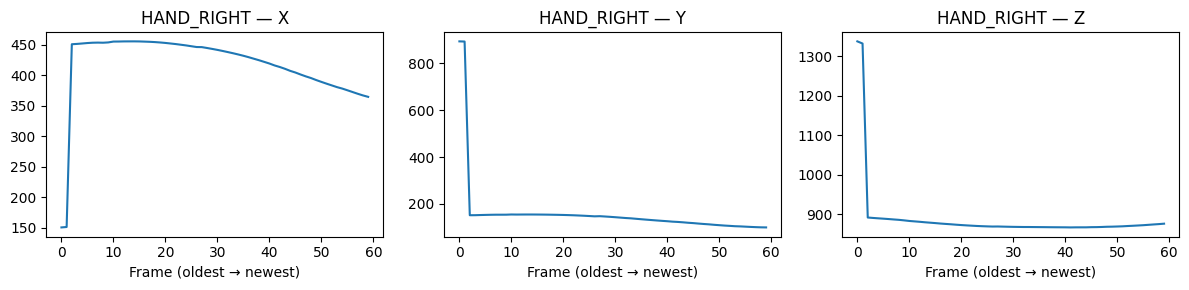

In [21]:
tensor, ts = window.to_tensor()
hand_idx = marker_names.index("HAND_RIGHT")
hand_traj = tensor[:, hand_idx, :]  # shape (60, 3)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for i, axis in enumerate(["X", "Y", "Z"]):
    axes[i].plot(hand_traj[:, i])
    axes[i].set_title(f"HAND_RIGHT — {axis}")
    axes[i].set_xlabel("Frame (oldest → newest)")
plt.tight_layout()
plt.show()

## 6. Dynamic Resizing with the `max_length` Setter

You can change the buffer capacity at runtime. The window **preserves as many recent frames as possible**:

In [22]:
w = SlidingWindow(max_length=10, n_signals=1, n_dims=1)
for i in range(10):
    w.append(float(i))
print(f"Before resize: size={len(w)}, max={w.max_length}")

w.max_length = 5   # Shrink — only the 5 most recent frames are kept
tensor, _ = w.to_tensor()
print(f"After shrink to 5: values={tensor.ravel()}")

w.max_length = 20  # Expand — new capacity, existing 5 frames preserved
print(f"After expand to 20: size={len(w)}, max={w.max_length}")

Before resize: size=10, max=10
After shrink to 5: values=[5. 6. 7. 8. 9.]
After expand to 20: size=5, max=20


**Expected:**
```
Before resize: size=10, max=10
After shrink to 5: values=[5. 6. 7. 8. 9.]
After expand to 20: size=5, max=20
```

> **When is this useful?** Adaptive analysis systems can shrink the window when a movement becomes fast and erratic (requiring less latency) or widen it when analysing slow, sustained gestures.

## 7. `reset()` — Clearing State Between Trials

When loading a new trial or restarting an experiment, always call `reset()` to erase historical data:

In [23]:
window.reset()
print(f"After reset: size={len(window)}, is_full={window.is_full}")
# → After reset: size=0, is_full=False

After reset: size=0, is_full=False


> Failing to reset between trials is a common source of subtle bugs: the first computed features of a new trial would be contaminated by the tail of the previous one.

## 8. Thread Safety

`SlidingWindow` uses a `threading.RLock` internally. This means `append` and `to_tensor` are safe to call from different threads simultaneously — a critical property for systems where a **producer thread** (reading from the sensor) and a **consumer thread** (running feature extraction) operate concurrently.

In [24]:
import threading

producer_window = SlidingWindow(max_length=100, n_signals=1, n_dims=3)

def producer():
    for t in range(500):
        producer_window.append(np.random.rand(1, 3))

def consumer():
    import time
    time.sleep(0.01)  # Let the producer run ahead
    tensor, _ = producer_window.to_tensor()
    print(f"Consumer read {len(tensor)} frames safely")

t1 = threading.Thread(target=producer)
t2 = threading.Thread(target=consumer)
t1.start(); t2.start()
t1.join(); t2.join()

Consumer read 100 frames safely


## 9. 🧪 Experiment: Adapting to Your Sensor Data

The `SlidingWindow` parameters must match your sensor's output format. Use the table below to determine the right configuration.

| Sensor | `n_signals` | `n_dims` | Typical `max_length` (at sensor Hz) |
|--------|------------|---------|-------------------------------------|
| Qualisys optical (skeleton, 21 joints) | 21 | 3 | 60–120 |
| Kinect skeleton (up to 25 joints) | 25 | 3 | 30–60 |
| Body-worn IMU (accelerometer + gyroscope) | 1–6 | 3 | 50–200 |
| Derived scalar (speed, energy) | 1 | 1 | 60–300 |

**Try the following with your own data:**

In [ ]:
# Replace with one of the available trial files and the appropriate loader
pos_tensor, vel_tensor, acc_tensor, marker_names = load_qualisys_tsv("data/YOUR_TRIAL.tsv")

N_joints = pos_tensor.shape[1]
N_dims   = pos_tensor.shape[2]

# Choose a window length corresponding to ~0.5 seconds of data
# (adjust based on the sampling rate of your file)
RATE_HZ = 100  # Change to match your file
WINDOW_SECONDS = 0.5
window = SlidingWindow(
    max_length=int(RATE_HZ * WINDOW_SECONDS),
    n_signals=N_joints,
    n_dims=N_dims
)

# Fill the window
for t in range(pos_tensor.shape[0]):
    window.append(pos_tensor[t])

tensor, ts = window.to_tensor()
print(f"Window filled. Shape: {tensor.shape}")
print(f"Duration covered: {tensor.shape[0] / RATE_HZ:.2f} s")

Try varying `WINDOW_SECONDS` between `0.1` and `3.0` and observe how the shape of the extracted tensor changes. This directly determines how much "memory" every subsequent feature extraction will have access to.

---

## Summary

| Concept | Key Point |
|---------|-----------|
| **Circular buffer** | Fixed-size; oldest frames are overwritten when full |
| **3-D shape** | Always `(Time, Signals, Dimensions)` — time is the leading axis |
| **`is_full`** | Guard condition before running any feature that requires a full window |
| **`to_tensor()`** | Primary extraction — chronological 3-D array |
| **`to_flat_array()`** | Flattened view — useful for ML pipelines |
| **`max_length` setter** | Runtime resize, preserving the most recent frames |
| **`reset()`** | Always call between trials to avoid data contamination |
| **Thread safety** | `RLock` protects all reads and writes |

In **Notebook 2**, we will use the `SlidingWindow` as the input to actual feature extractors and discover why the distinction between *Static* and *Dynamic* features completely determines how you size this buffer.